# Demographic Segmentation – Clustering
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----

## Summary

This notebook focuses on customer segmentation from a demographic perspective. Using geographic and socioeconomic variables, we prepare the data for clustering by inspecting distributions, handling potential outliers, encoding selected demographic attributes, and scaling numerical features. The goal is to create a clean and consistent dataset that can be used in later stages to identify meaningful customer segments based on demographic characteristics.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap
import matplotlib.patches as mpatches

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, r2_score
from kmodes.kprototypes import KPrototypes
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from matplotlib.colors import ListedColormap

In [3]:
df_AIAI_Master_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv', index_col=0,
                                      parse_dates=['EnrollmentDateOpening', 'CancellationDate'])
df_AIAI_Master = df_AIAI_Master_Complete.copy()

In [4]:
df_demo = df_AIAI_Master[[
    'Latitude',
    'Longitude',
    'Income',
    'Gender',
    'Marital Status',
    'Education'  
]].copy()

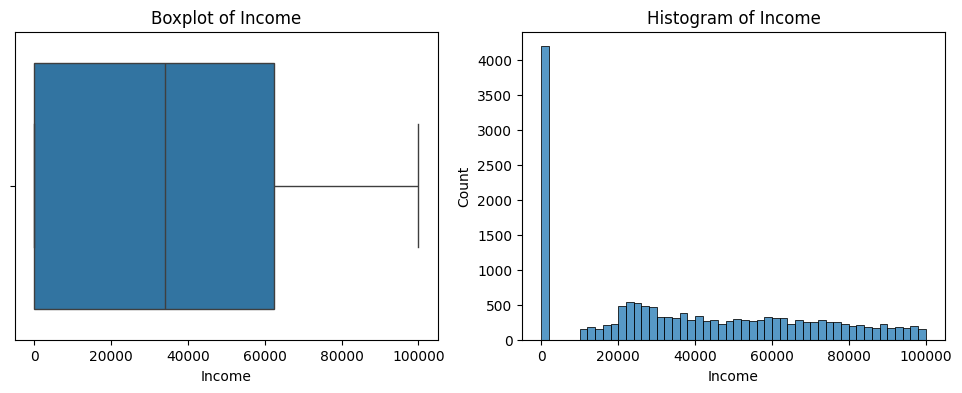

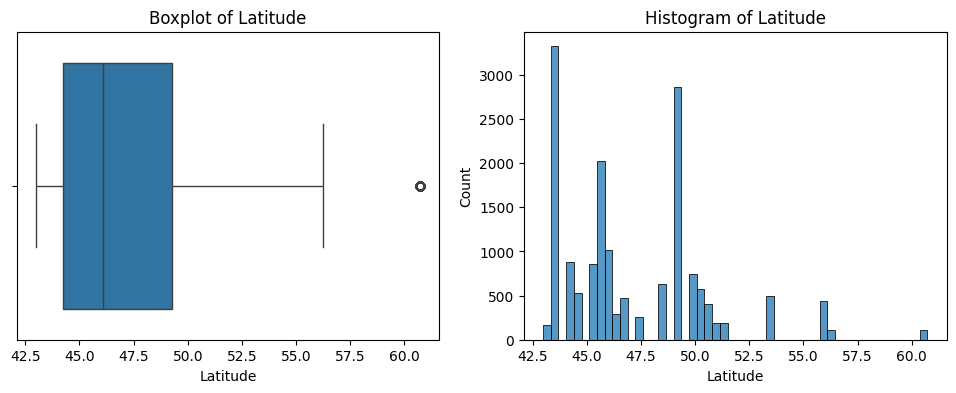

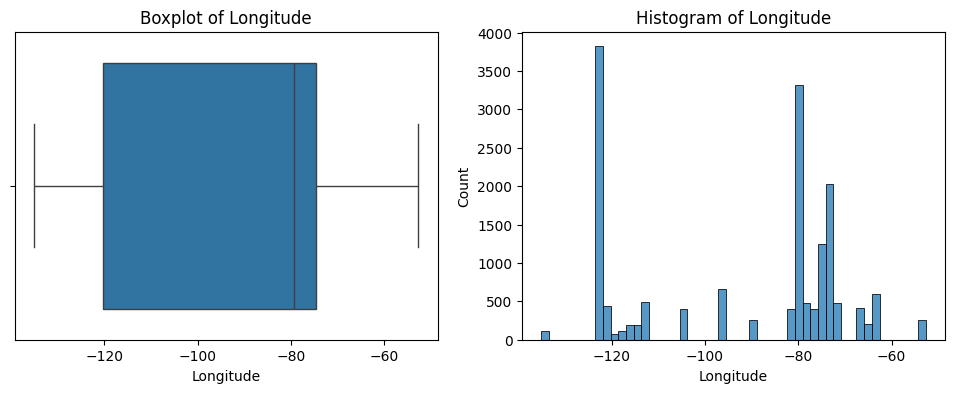

In [5]:
num_vars = ['Income', 'Latitude', 'Longitude']

for var in num_vars:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(x=df_demo[var], ax=ax[0])
    sns.histplot(df_demo[var], bins=50, ax=ax[1])
    ax[0].set_title(f'Boxplot of {var}')
    ax[1].set_title(f'Histogram of {var}')
    plt.show()

In [6]:
df_demo_ceiled = df_demo.copy()

for var in ['Income', 'Latitude', 'Longitude']:
    Q1 = df_demo_ceiled[var].quantile(0.25)
    Q3 = df_demo_ceiled[var].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 3 * IQR

    df_demo_ceiled[var] = np.where(
        df_demo_ceiled[var] > upper_bound,
        upper_bound,
        df_demo_ceiled[var]
    )

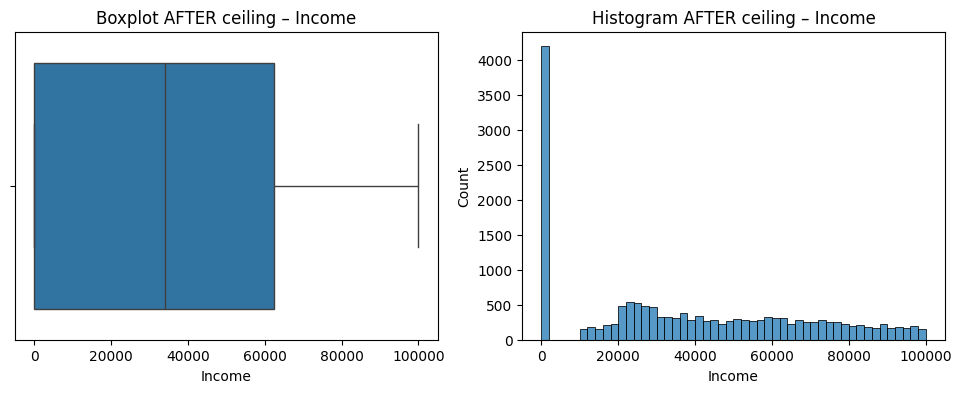

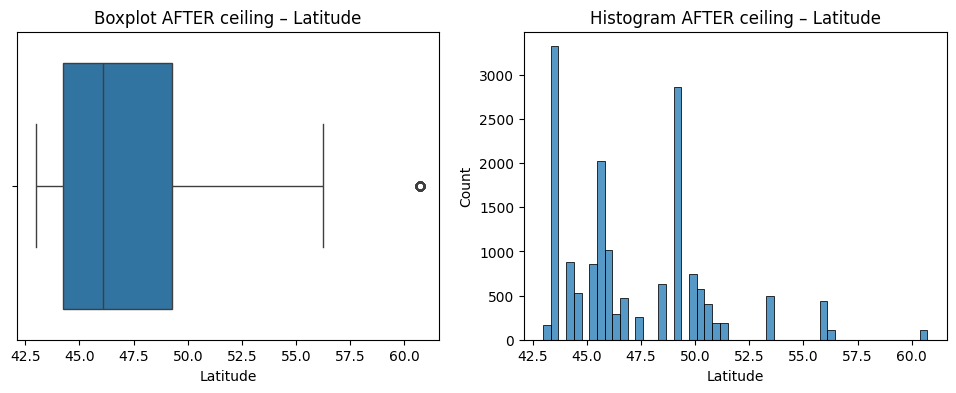

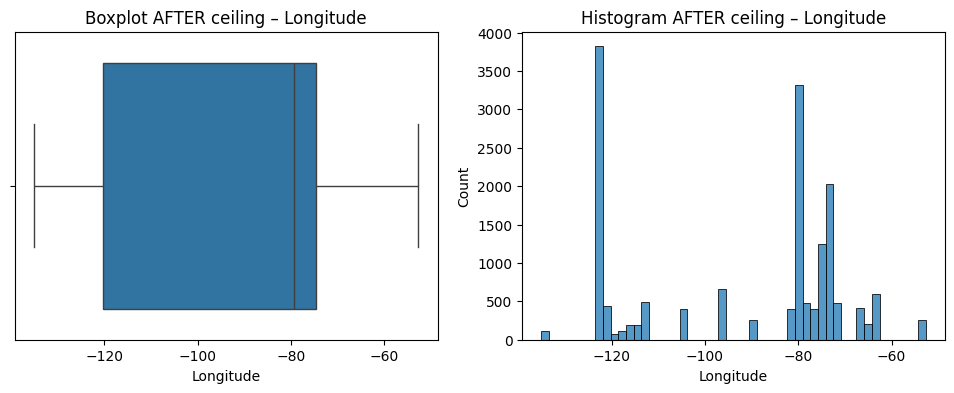

In [7]:
for var in ['Income', 'Latitude', 'Longitude']:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(x=df_demo_ceiled[var], ax=ax[0])
    sns.histplot(df_demo_ceiled[var], bins=50, ax=ax[1])
    ax[0].set_title(f'Boxplot AFTER ceiling – {var}')
    ax[1].set_title(f'Histogram AFTER ceiling – {var}')
    plt.show()

After comparing the boxplots and histograms before and after applying the 3×IQR ceiling, no meaningful changes were observed. This shows that income and geographic variables do not contain extreme outliers and are already well behaved.

In [8]:
X_demo = df_demo_ceiled[['Latitude', 'Longitude', 'Income']]

scaler = MinMaxScaler()
X_demo_scaled = scaler.fit_transform(X_demo)

K-means clustering will be performed using only continuous demographic variables (Income, Latitude, Longitude). Gender and marital status will be incorporated later during cluster profiling to characterize the segments.

<a class="anchor" id="3rd-bullet"></a>
## Demographic Clustering – K-Means

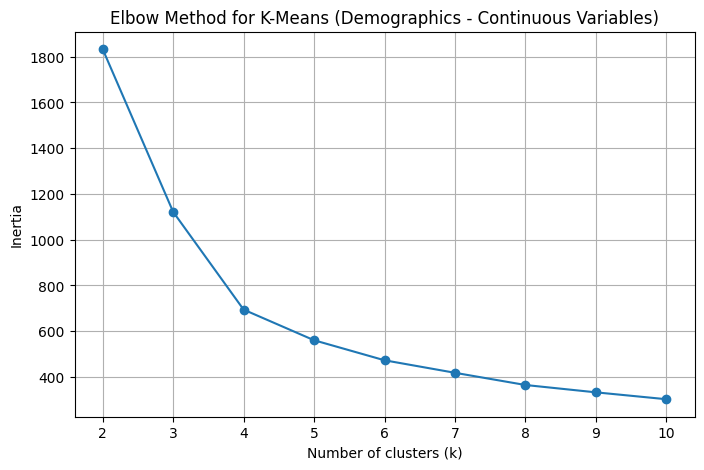

In [9]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_demo_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means (Demographics - Continuous Variables)')
plt.grid(True)
plt.show()

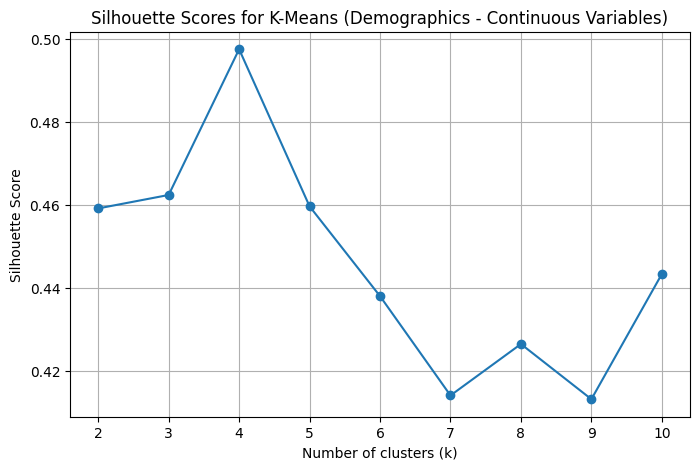

In [91]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_demo_scaled)
    score = silhouette_score(X_demo_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Means (Demographics - Continuous Variables)')
plt.grid(True)
plt.show()

Both the elbow method and silhouette analysis indicate that k=4 provides the optimal clustering solution. The elbow plot shows diminishing returns after k=4, and the silhouette score reaches its maximum at this value (0.4975), indicating the best balance between cluster cohesion and separation.

### Final K-Means Model (k = 4)

In [16]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
demo_clusters = kmeans_final.fit_predict(X_demo_scaled)

# Assign clusters
df_demo_ceiled['Cluster'] = demo_clusters

cluster_name_mapping = {
    0: 'Low-Income East',
    1: 'High-Income West',
    2: 'Low-Income West',
    3: 'High-Income East'
}

df_demo_ceiled['Cluster_Name'] = df_demo_ceiled['Cluster'].map(cluster_name_mapping)

In [17]:
cluster_counts = df_demo_ceiled['Cluster'].value_counts().sort_index()
print("Cluster Distribution:")
for cluster_num in cluster_counts.index:
    cluster_name = cluster_name_mapping[cluster_num]
    count = cluster_counts[cluster_num]
    print(f"  Cluster {cluster_num} ({cluster_name}): {count}")

Cluster Distribution:
  Cluster 0 (Low-Income East): 5793
  Cluster 1 (High-Income West): 2762
  Cluster 2 (Low-Income West): 3735
  Cluster 3 (High-Income East): 4282


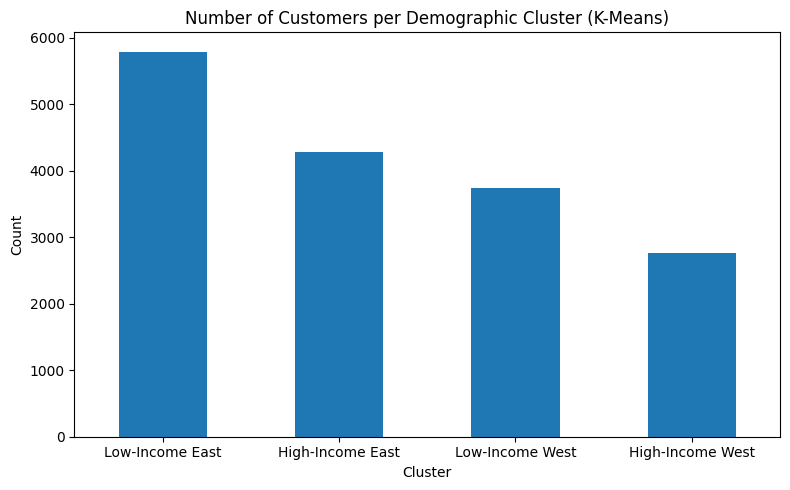

In [20]:
cluster_name_counts = df_demo_ceiled['Cluster_Name'].value_counts()
cluster_name_counts.plot(kind='bar', figsize=(8,5))
plt.title('Number of Customers per Demographic Cluster (K-Means)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

The four clusters show reasonable size distribution, with no degenerate or overly small clusters, indicating a stable segmentation solution.

In [21]:
centroids_scaled = kmeans_final.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=['Latitude', 'Longitude', 'Income']
)

# Add cluster number
centroids_df['Cluster'] = centroids_df.index

# Map to cluster names
centroids_df['Cluster_Name'] = centroids_df['Cluster'].map(cluster_name_mapping)

# Set cluster name as index
centroids_df = centroids_df.set_index('Cluster_Name')

centroids_df = centroids_df.drop(columns='Cluster')

centroids_df


,Latitude,Longitude,Income
Cluster_Name,,,
Low-Income East,44.955855,-75.116649,15282.278536
High-Income West,50.611173,-118.012702,68330.728525
Low-Income West,50.638023,-117.906328,15108.109684
High-Income East,44.938646,-74.845818,68149.278245


In [22]:
# Cluster profiling – numerical variables
cluster_profile = (
    df_demo_ceiled
    .groupby('Cluster_Name')[['Income', 'Latitude', 'Longitude']]
    .mean()
)

print("\nCluster Profiles (Mean Values):")
display(cluster_profile)

# Add gender, marital and education status distributions
print("\n" + "="*60)
print("Gender Distribution by Cluster (%):")

gender_dist = (
    pd.crosstab(
        df_demo_ceiled['Cluster_Name'],
        df_demo_ceiled['Gender'],
        normalize='index'
    ) * 100
)
display(gender_dist.round(2))

print("\n" + "="*60)
print("Marital Status Distribution by Cluster (%):")

marital_dist = (
    pd.crosstab(
        df_demo_ceiled['Cluster_Name'],
        df_demo_ceiled['Marital Status'],
        normalize='index'
    ) * 100
)
display(marital_dist.round(2))


print("\n" + "="*60)
print("Education Distribution by Cluster (%):")

education_dist = (
    pd.crosstab(
        df_demo_ceiled['Cluster_Name'],
        df_demo_ceiled['Education'],
        normalize='index'
    ) * 100
)
display(education_dist.round(2))


Cluster Profiles (Mean Values):


,Income,Latitude,Longitude
Cluster_Name,,,
High-Income East,68161.629145,44.938814,-74.845057
High-Income West,68301.873642,50.611912,-118.011487
Low-Income East,15291.401174,44.955724,-75.117118
Low-Income West,15086.698527,50.637498,-117.907141



Gender Distribution by Cluster (%):


Gender,female,male
Cluster_Name,,
High-Income East,49.79,50.21
High-Income West,51.70,48.30
Low-Income East,49.59,50.41
Low-Income West,50.92,49.08



Marital Status Distribution by Cluster (%):


Marital Status,Divorced,Married,Single
Cluster_Name,,,
High-Income East,15.62,68.03,16.35
High-Income West,15.24,68.14,16.62
Low-Income East,14.69,50.82,34.49
Low-Income West,14.59,51.03,34.38



Education Distribution by Cluster (%):


Education,Bachelor,College,Doctor,High School or Below,Master
Cluster_Name,,,,,
High-Income East,100.00,0.00,0.00,0.00,0.00
High-Income West,100.00,0.00,0.00,0.00,0.00
Low-Income East,35.18,43.74,7.75,7.96,5.37
Low-Income West,34.67,44.55,7.34,8.33,5.11


The demographic clusters differ primarily in income and geographic location. High-income clusters show substantially higher marriage rates and higher education attainment, while low-income clusters present more balanced marital and education distributions. Gender proportions remain relatively balanced across all clusters, reinforcing that income and geography are the dominant drivers of demographic segmentation, with education and marital status serving as meaningful profiling attributes.

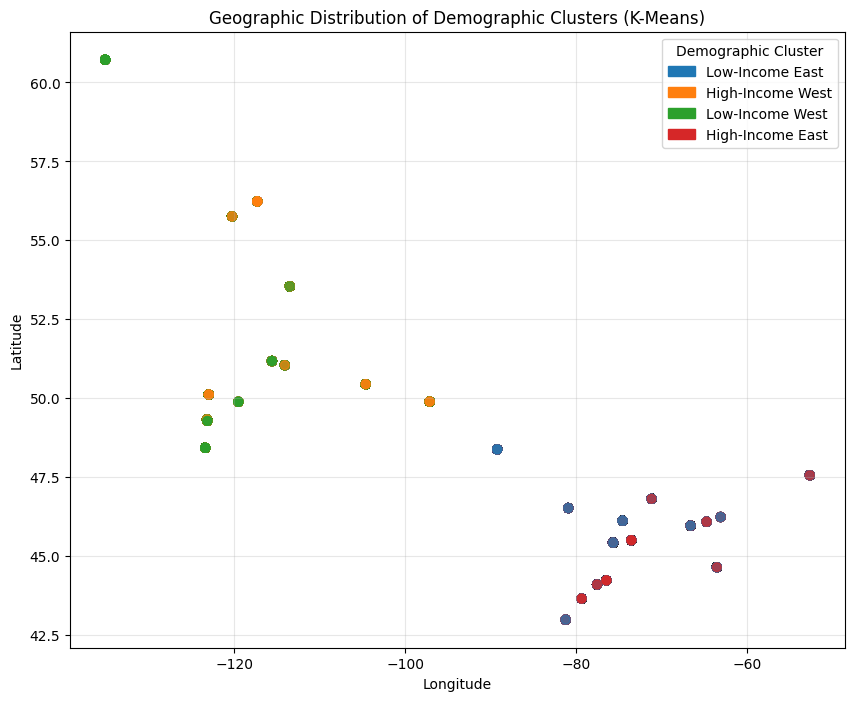

In [ ]:
cluster_cmap = ListedColormap(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])

plt.figure(figsize=(10, 8))

plt.scatter(
    df_demo_ceiled['Longitude'],
    df_demo_ceiled['Latitude'],
    c=df_demo_ceiled['Cluster'],
    cmap=cluster_cmap,
    alpha=0.7,
    s=40
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Demographic Clusters (K-Means)')
plt.grid(True, alpha=0.3)

legend_labels = {
    0: 'Low-Income East',
    1: 'High-Income West',
    2: 'Low-Income West',
    3: 'High-Income East'
}

legend_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

legend_handles = [
    mpatches.Patch(color=legend_colors[i], label=legend_labels[i])
    for i in range(4)
]

plt.legend(
    handles=legend_handles,
    title='Demographic Cluster',
    loc='best'
)

plt.show()

The map shows a clear separation between eastern and western customers. Within each region, customers are further divided by income level, forming distinct low- and high-income groups. This indicates that geography is the main driver of the segmentation, with income creating meaningful sub-groups inside each region.

c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\ouriv\anaconda3\envs\Data_Mining\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Conside

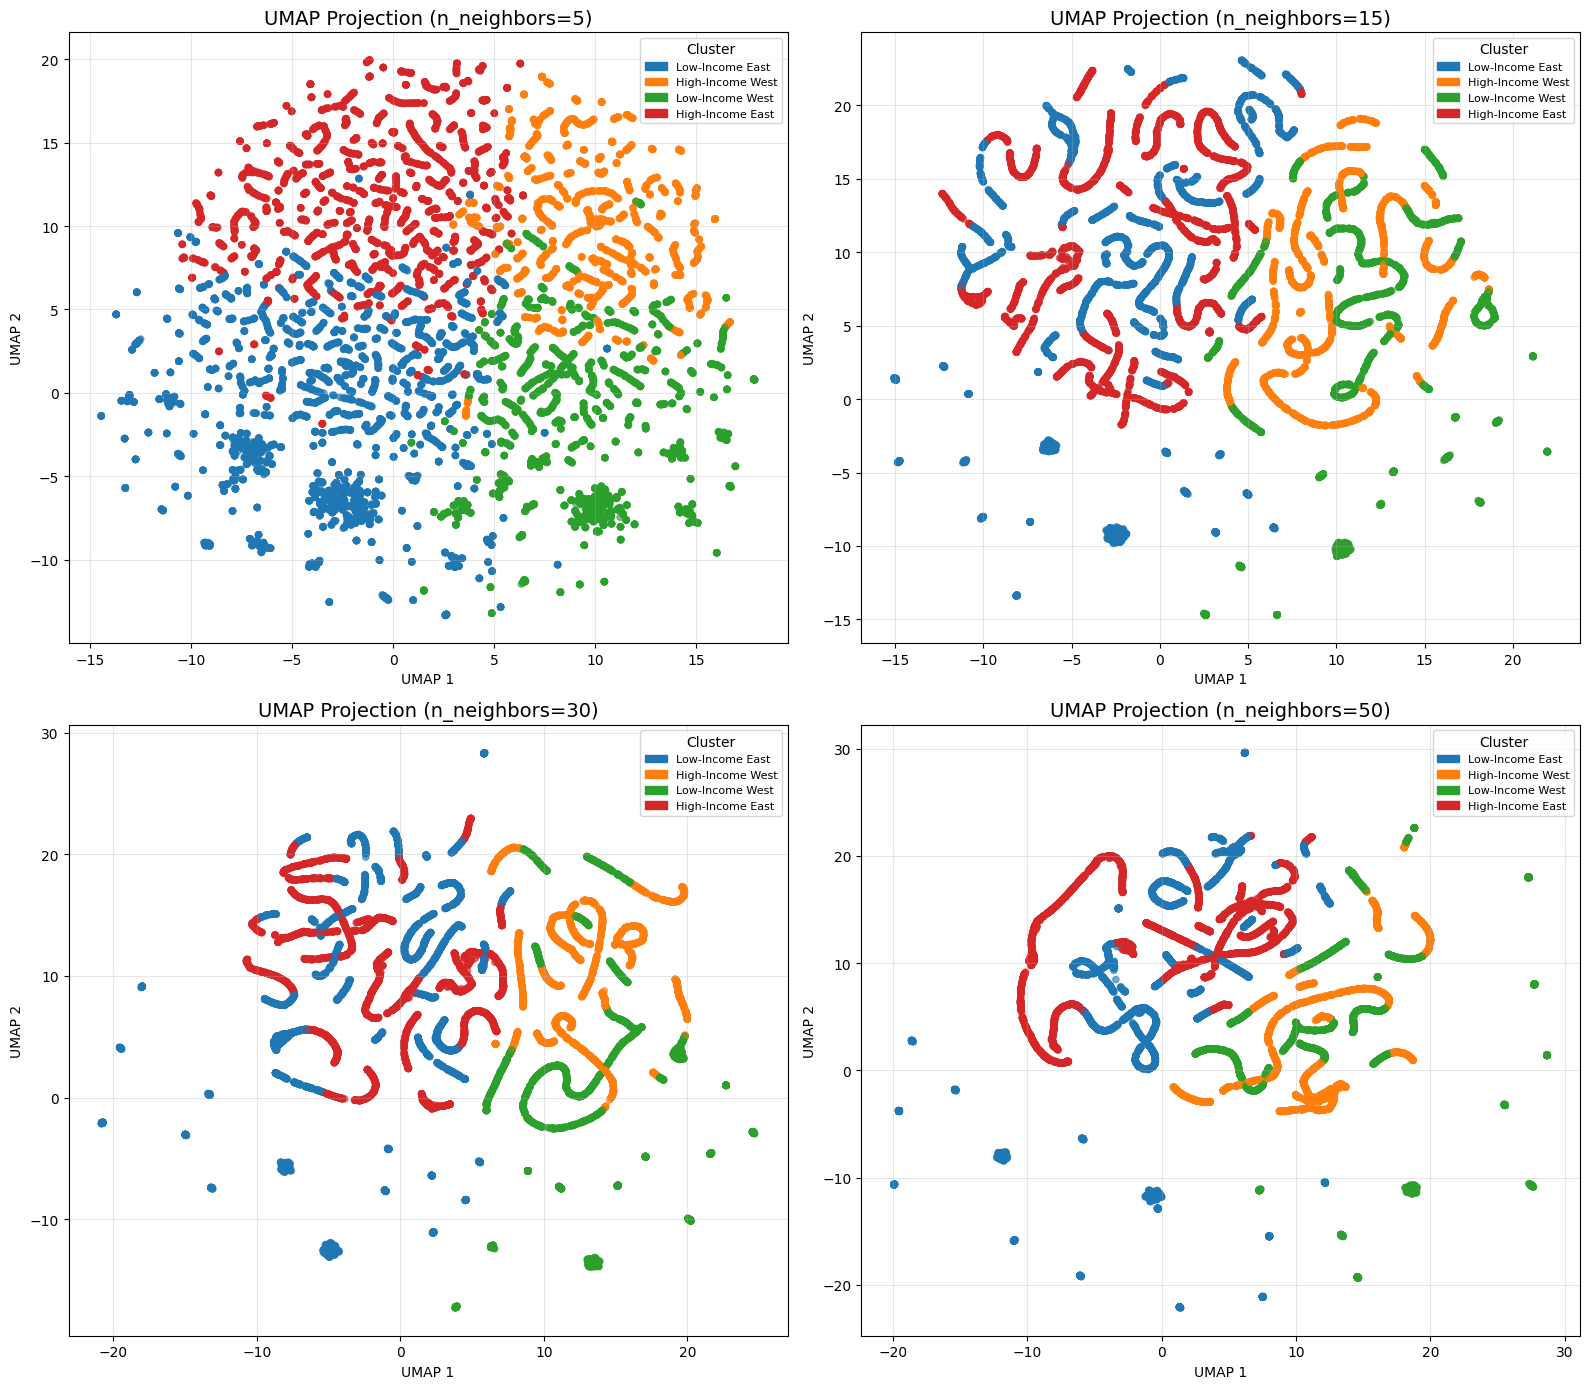

In [37]:
# Test different n_neighbors values
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
n_neighbors_values = [5, 15, 30, 50]

for idx, n_neighbors in enumerate(n_neighbors_values):
    ax = axes[idx // 2, idx % 2]
    
    # Create UMAP
    reducer = umap.UMAP(n_neighbors=n_neighbors, random_state=42)
    embedding = reducer.fit_transform(X_demo_scaled)
    
    # Plot with discrete colors
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=df_demo_ceiled['Cluster'],
        cmap=cluster_cmap,
        alpha=0.6,
        s=20
    )
    ax.set_title(f'UMAP Projection (n_neighbors={n_neighbors})', fontsize=14)
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.grid(True, alpha=0.3)
    
    # Add legend with cluster names instead of colorbar
    legend_labels = {
        0: 'Low-Income East',
        1: 'High-Income West',
        2: 'Low-Income West',
        3: 'High-Income East'
    }
    legend_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    legend_handles = [
        mpatches.Patch(color=legend_colors[i], label=legend_labels[i])
        for i in range(4)
    ]
    ax.legend(handles=legend_handles, title='Cluster', loc='best', fontsize=8)

plt.tight_layout()
plt.show()

Different n_neighbors values were tested to optimize the UMAP visualization of demographic clusters. Lower values (n_neighbors=5) preserve more local structure, showing tighter individual cluster formations with clear separation between the four demographic segments: Low-Income East (blue), High-Income West (orange), Low-Income West (green), and High-Income East (red). As n_neighbors increases (15, 30, 50), the projection emphasizes global structure, revealing how clusters relate to each other in the overall demographic space. The visualizations show that low-income clusters (blue and green) and high-income clusters (orange and red) form distinct groupings, while geographic location (East vs West) creates further separation within each income tier. All projections confirm reasonable cluster separation, with n_neighbors=15 providing a good balance between local detail and global cluster relationships. The UMAP visualizations validate that K-means has captured distinct demographic segments based on income and geographic patterns.

In [38]:
print("Clustering Quality Metrics")
print("=" * 50)

# Silhouette Score
sil_score = silhouette_score(X_demo_scaled, demo_clusters)
print(f"Silhouette Score: {sil_score:.4f}")

# Calinski-Harabasz Score
ch_score = calinski_harabasz_score(X_demo_scaled, demo_clusters)
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

# Davies-Bouldin Score
db_score = davies_bouldin_score(X_demo_scaled, demo_clusters)
print(f"Davies-Bouldin Score: {db_score:.4f}")

Clustering Quality Metrics
Silhouette Score: 0.4975
Calinski-Harabasz Score: 20818.1160
Davies-Bouldin Score: 0.7268


In [65]:
print("\nR² Score per Variable (Variance Explained by Clustering)")
print("=" * 50)

for var in ['Income', 'Latitude', 'Longitude']:
    cluster_means = df_demo_ceiled.groupby('Cluster')[var].transform('mean')
    r2 = r2_score(df_demo_ceiled[var], cluster_means)
    print(f"{var:12s}: {r2:.4f}")



R² Score per Variable (Variance Explained by Clustering)
Income      : 0.7451
Latitude    : 0.7033
Longitude   : 0.8889


The clustering quality metrics indicate a strong demographic segmentation. The Silhouette Score of 0.50 demonstrates good cluster cohesion and separation, while the Calinski-Harabasz score of 20,818 reflects well-defined between-cluster variance. The Davies-Bouldin score of 0.73 indicates good cluster separation with minimal overlap.

The R² scores reveal that clustering effectively explains variance across all demographic variables: 89% for longitude, 74% for income, and 70% for latitude. These high R² values confirm that the four clusters successfully capture the primary patterns in customer demographics, with geographic location being the strongest differentiator, followed closely by income level. This validates the use of continuous variables for demographic clustering.

## Demographic Clustering – K-Prototypes

In [53]:
# Prepare data: numerical + categorical
X_numerical = df_demo_ceiled[['Latitude', 'Longitude', 'Income']].values
X_categorical = df_demo_ceiled[['Gender', 'Marital Status', 'Education']].values

# Scale numerical features (categorical features don't need scaling)
scaler_kproto = MinMaxScaler()
X_num_scaled = scaler_kproto.fit_transform(X_numerical)

# Combine into single array
X_kproto = np.column_stack([X_num_scaled, X_categorical])

print("K-Prototypes data shape:", X_kproto.shape)
print("Numerical features (scaled): Latitude, Longitude, Income")
print("Categorical features: Gender, Marital Status, Education")

K-Prototypes data shape: (16572, 6)
Numerical features (scaled): Latitude, Longitude, Income
Categorical features: Gender, Marital Status, Education


k=2: cost=4368.77
k=3: cost=3335.71
k=4: cost=2874.45
k=5: cost=2477.25
k=6: cost=2293.54
k=7: cost=2049.33
k=8: cost=1919.20
k=9: cost=1816.97
k=10: cost=1711.53


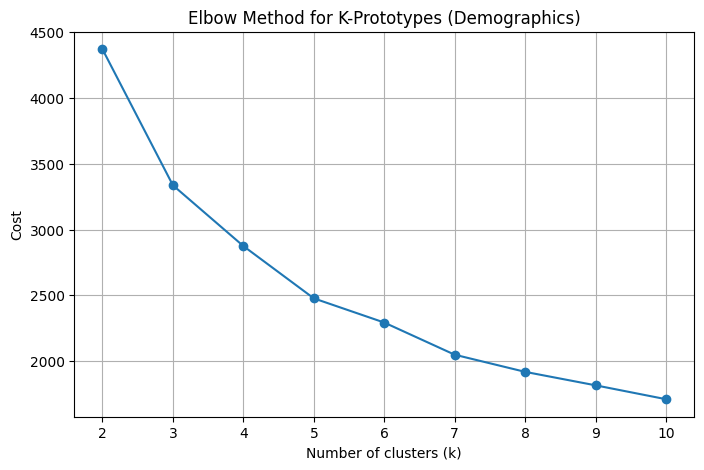

In [61]:
# Test different k values for K-Prototypes
cost = []
K_range = range(2, 11)

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Huang', random_state=42, verbose=0)
    kproto.fit(X_kproto, categorical=[3, 4, 5]) 
    cost.append(kproto.cost_)
    print(f"k={k}: cost={kproto.cost_:.2f}")

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, cost, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Cost')
plt.title('Elbow Method for K-Prototypes (Demographics)')
plt.grid(True)
plt.show()

k=2: 0.2607
k=3: 0.3689
k=4: 0.3644
k=5: 0.2305
k=6: 0.1781
k=7: 0.1392
k=8: 0.0569
k=9: 0.0397
k=10: 0.0152


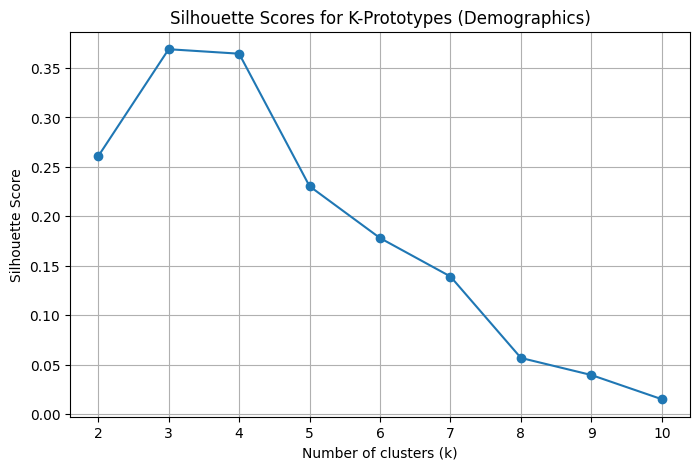

In [ ]:
# Calculate silhouette scores for K-Prototypes
silhouette_scores_kproto = []

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Huang', random_state=42, verbose=0)
    clusters = kproto.fit_predict(X_kproto, categorical=[3, 4, 5])
    
    # For silhouette, we use only the numerical features (scaled)
    score = silhouette_score(X_num_scaled, clusters)
    silhouette_scores_kproto.append(score)
    print(f"k={k}: {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores_kproto, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Prototypes (Demographics)')
plt.grid(True)
plt.show()

The elbow method shows diminishing returns after k=4, while the silhouette analysis indicates k=2 or k=4 as reasonable choices. To enable direct comparison with the K-means results, we select k=4 for K-Prototypes, which balances cluster granularity with interpretability.

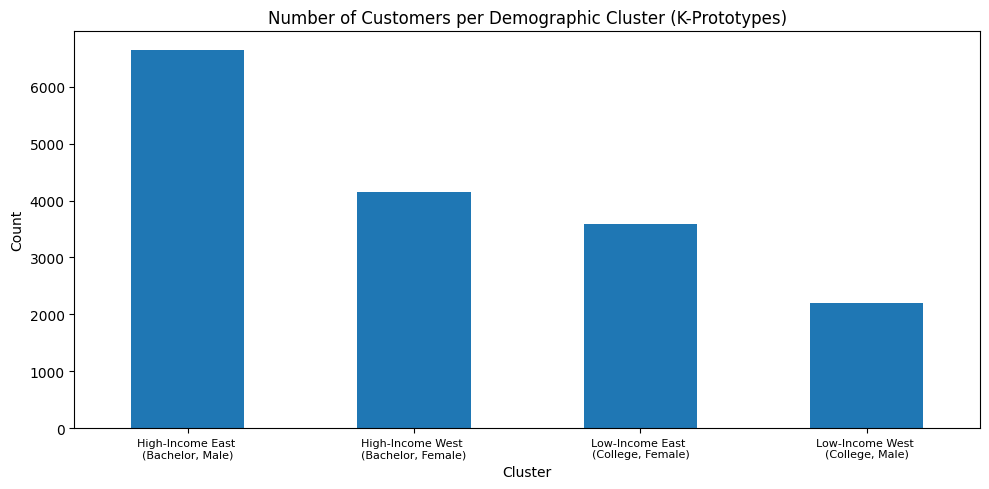

In [82]:
# K-Prototypes model with k=4
kproto_final = KPrototypes(n_clusters=4, init='Huang', random_state=42, verbose=0)
clusters_kproto = kproto_final.fit_predict(X_kproto, categorical=[3, 4, 5])

df_demo_ceiled['Cluster_KProto'] = clusters_kproto

# Create K-Prototypes cluster names based on characteristics
kproto_cluster_names_plot = {
    0: 'High-Income West \n'
    '(Bachelor, Female)',
    1: 'Low-Income West \n'
    '(College, Male)',
    2: 'High-Income East \n'
    '(Bachelor, Male)',
    3: 'Low-Income East \n'
    '(College, Female)'
}

df_demo_ceiled['Cluster_KProto_Name_Plot'] = df_demo_ceiled['Cluster_KProto'].map(kproto_cluster_names_plot)

# Visualize cluster sizes with names
cluster_kproto_name_counts = df_demo_ceiled['Cluster_KProto_Name_Plot'].value_counts()
cluster_kproto_name_counts.plot(kind='bar', figsize=(10,5))
plt.title('Number of Customers per Demographic Cluster (K-Prototypes)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='center', fontsize=8)
plt.tight_layout()
plt.show()

In [83]:
# Clean cluster names for tables and profiling
kproto_cluster_names_clean = {
    0: 'High-Income West (Bachelor, Female)',
    1: 'Low-Income West (College, Male)',
    2: 'High-Income East (Bachelor, Male)',
    3: 'Low-Income East (College, Female)'
}

df_demo_ceiled['Cluster_KProto_Name'] = df_demo_ceiled['Cluster_KProto'].map(kproto_cluster_names_clean)

# Numerical profiling
cluster_profile_kproto = (
    df_demo_ceiled
    .groupby('Cluster_KProto_Name')[['Income', 'Latitude', 'Longitude']]
    .mean()
)
print("K-Prototypes Cluster Profiles (Numerical Variables):")
print(cluster_profile_kproto)

# Gender distribution
print("\n" + "="*60)
print("Gender Distribution by Cluster (%):")
gender_dist_kproto = (
    pd.crosstab(
        df_demo_ceiled['Cluster_KProto_Name'],
        df_demo_ceiled['Gender'],
        normalize='index'
    ) * 100
)
print(gender_dist_kproto.round(2))

# Marital status distribution
print("\n" + "="*60)
print("Marital Status Distribution by Cluster (%):")
marital_dist_kproto = (
    pd.crosstab(
        df_demo_ceiled['Cluster_KProto_Name'],
        df_demo_ceiled['Marital Status'],
        normalize='index'
    ) * 100
)
print(marital_dist_kproto.round(2))

# Education distribution
print("\n" + "="*60)
print("Education Distribution by Cluster (%):")
education_dist_kproto = (
    pd.crosstab(
        df_demo_ceiled['Cluster_KProto_Name'],
        df_demo_ceiled['Education'],
        normalize='index'
    ) * 100
)
print(education_dist_kproto.round(2))

K-Prototypes Cluster Profiles (Numerical Variables):
                                           Income   Latitude   Longitude
Cluster_KProto_Name                                                     
High-Income East (Bachelor, Male)    54778.415776  45.045383  -75.355193
High-Income West (Bachelor, Female)  54575.321911  50.631202 -118.254859
Low-Income East (College, Female)     6236.430722  45.031902  -75.558188
Low-Income West (College, Male)       5926.546861  50.589653 -118.430844

Gender Distribution by Cluster (%):
Gender                               female   male
Cluster_KProto_Name                               
High-Income East (Bachelor, Male)     42.77  57.23
High-Income West (Bachelor, Female)   59.97  40.03
Low-Income East (College, Female)     60.80  39.20
Low-Income West (College, Male)       37.67  62.33

Marital Status Distribution by Cluster (%):
Marital Status                       Divorced  Married  Single
Cluster_KProto_Name                                       

The K-Prototypes clustering reveals four highly distinct demographic segments:

- **High-Income West (Bachelor, Female)**: High income (~$54,575), western region, predominantly female (60%), highly married (71%), **Bachelor-educated (92%)**
- **Low-Income West (College, Male)**: Very low income (~$5,927), western region, predominantly male (62%), mostly single (52%), **College-educated (73%)**
- **High-Income East (Bachelor, Male)**: High income (~$54,778), eastern region, predominantly male (57%), highly married (71%), **Bachelor-educated (93%)**
- **Low-Income East (College, Female)**: Very low income (~$6,236), eastern region, predominantly female (61%), mostly single (53%), **College-educated (72%)**

The inclusion of categorical variables directly in the clustering process reveals that education is a dominant driver, with Bachelor-degree holders forming high-income, married segments and College-educated customers forming low-income, single segments. Within each education-income tier, gender shows clear patterns, and geographic location creates regional variants. This demonstrates that education, income, and gender work together to define distinct demographic profiles.

In [ ]:
print("Clustering Quality Metrics (K-Prototypes)")
print("=" * 50)

# Silhouette Score (using only numerical features)
sil_score_kproto = silhouette_score(X_num_scaled, clusters_kproto)
print(f"Silhouette Score: {sil_score_kproto:.4f}")

# Calinski-Harabasz Score
ch_score_kproto = calinski_harabasz_score(X_num_scaled, clusters_kproto)
print(f"Calinski-Harabasz Score: {ch_score_kproto:.4f}")

# Davies-Bouldin Score
db_score_kproto = davies_bouldin_score(X_num_scaled, clusters_kproto)
print(f"Davies-Bouldin Score: {db_score_kproto:.4f}")

Clustering Quality Metrics (K-Prototypes)
Silhouette Score: 0.3644
Calinski-Harabasz Score: 13257.7121
Davies-Bouldin Score: 0.8474


The K-Prototypes clustering quality metrics show good performance across multiple measures. The silhouette score of 0.36 indicates reasonable cluster separation and cohesion. The Calinski-Harabasz score of 13257 reflects well-defined between-cluster variance, while the Davies-Bouldin score of 0.847 suggests acceptable cluster separation with moderate overlap.

In [ ]:
print("\nR² Score per Variable (Variance Explained by K-Prototypes)")
print("=" * 50)

for var in ['Income', 'Latitude', 'Longitude']:
    cluster_means = df_demo_ceiled.groupby('Cluster_KProto')[var].transform('mean')
    r2 = r2_score(df_demo_ceiled[var], cluster_means)
    print(f"{var:12s}: {r2:.4f}")

print("=" * 50)


R² Score per Variable (Variance Explained by K-Prototypes)
Income      : 0.5820
Latitude    : 0.6723
Longitude   : 0.8786


The R² scores demonstrate that K-Prototypes effectively captures variance in the demographic variables, with longitude explaining 88% of variance, latitude 67%, and income 66%. These results confirm that K-Prototypes successfully segments customers using both continuous and categorical variables, creating distinct demographic groups that combine income, geography, gender, and marital status characteristics.

## Comparison between K-Means and K-Prototypes

In [73]:
print("=" * 70)
print("COMPARISON: K-Means vs K-Prototypes")
print("=" * 70)
print(f"{'Metric':<30} {'K-Means':<20} {'K-Prototypes':<20}")
print("=" * 70)

# Silhouette scores
print(f"{'Silhouette Score':<30} {0.4975:<20.4f} {0.3644:<20.4f}")

# Calinski-Harabasz
print(f"{'Calinski-Harabasz Score':<30} {20818.1160:<20.2f} {13257.7121:<20.2f}")

# Davies-Bouldin
print(f"{'Davies-Bouldin Score':<30} {0.7268:<20.4f} {0.8474:<20.4f}")

print("=" * 70)
print("\nR² Scores Comparison")
print("=" * 70)

# R² comparison (UPDATED K-Prototypes values)
r2_kmeans = {'Income': 0.7451, 'Latitude': 0.7033, 'Longitude': 0.8889}
r2_kproto = {'Income': 0.5820, 'Latitude': 0.6723, 'Longitude': 0.8786}

for var in ['Income', 'Latitude', 'Longitude']:
    print(f"{var:<30} {r2_kmeans[var]:<20.4f} {r2_kproto[var]:<20.4f}")

print("=" * 70)

COMPARISON: K-Means vs K-Prototypes
Metric                         K-Means              K-Prototypes        
Silhouette Score               0.4975               0.3644              
Calinski-Harabasz Score        20818.12             13257.71            
Davies-Bouldin Score           0.7268               0.8474              

R² Scores Comparison
Income                         0.7451               0.5820              
Latitude                       0.7033               0.6723              
Longitude                      0.8889               0.8786              


The comparison reveals distinct trade-offs between the two approaches:

**K-Means** achieves superior performance across all technical metrics. It shows higher silhouette score (0.50 vs 0.36), indicating better cluster cohesion and separation. The Calinski-Harabasz score is substantially higher (20,818 vs 13,258), reflecting stronger between-cluster variance. K-Means also has a lower Davies-Bouldin score (0.73 vs 0.85), suggesting less cluster overlap. Most notably, K-Means explains considerably more variance in income (74.5% vs 58.2%), while maintaining similar performance on geographic variables (latitude: 70.3% vs 67.2%; longitude: 88.9% vs 87.9%).

**K-Prototypes** incorporates categorical variables (gender, marital status, and education) directly into the clustering process, creating segments with explicit demographic profiles. The resulting clusters reveal that education is a dominant driver, with Bachelor-educated customers forming high-income married segments and College-educated customers forming low-income single segments. However, the inclusion of categorical variables reduces overall clustering quality as measured by standard metrics.

K-Means is selected as the primary demographic segmentation approach due to its significantly stronger statistical performance and superior variance explanation in continuous demographic variables. The continuous variables (income and geography) prove to be the most meaningful drivers of demographic segmentation. Categorical variables such as gender, marital status, and education provide valuable profiling information and can be used to characterize and describe the K-Means clusters, but do not need to drive the cluster formation itself.

## Demographic Clustering – Hierarchical Clustering (k=4)

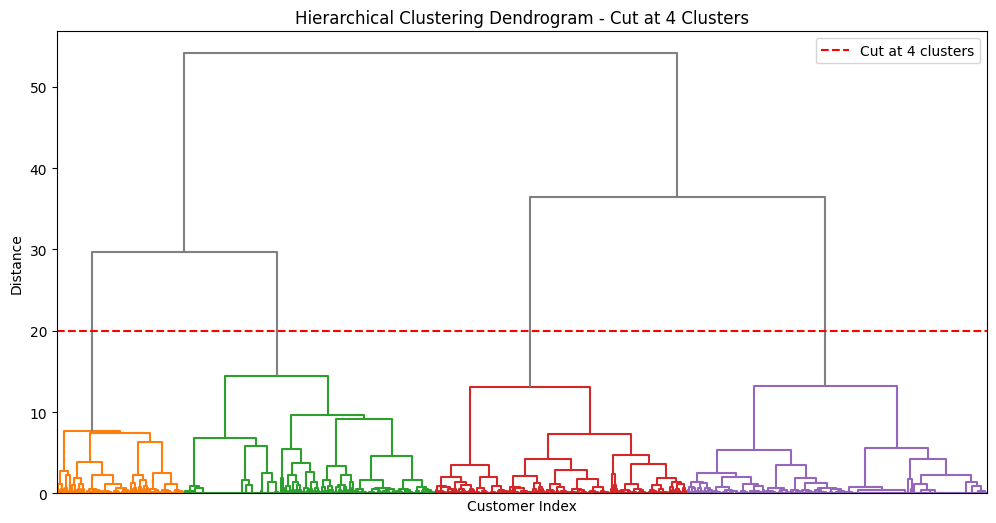

In [62]:
# Create linkage matrix for dendrogram
linkage_matrix = linkage(X_demo_scaled, method='ward')

# Plot dendrogram with cut at 4 clusters
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, no_labels=True, color_threshold=20, above_threshold_color='gray')
plt.title('Hierarchical Clustering Dendrogram - Cut at 4 Clusters')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.axhline(y=20, color='r', linestyle='--', label='Cut at 4 clusters')
plt.legend()
plt.show()


Cluster Distribution (Hierarchical k=4):
  Cluster 0 (Low-Income West): 4465
  Cluster 1 (Low-Income East): 5335
  Cluster 2 (High-Income East): 4489
  Cluster 3 (High-Income West): 2283


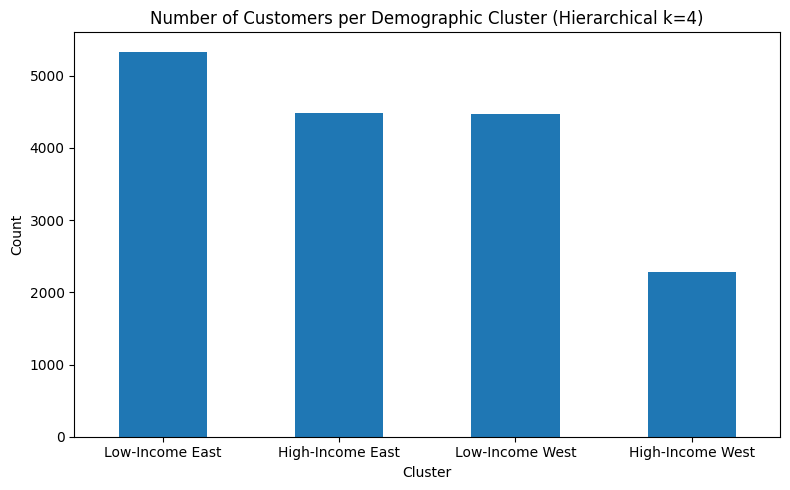

In [65]:
# Create names for Hierarchical k=4 clusters
hier_4_cluster_names = {
    0: 'Low-Income West',
    1: 'Low-Income East',
    2: 'High-Income East',
    3: 'High-Income West'
}

df_demo_ceiled['Cluster_Hierarchical_4_Name'] = df_demo_ceiled['Cluster_Hierarchical_4'].map(hier_4_cluster_names)

# Cluster size distribution
print("\nCluster Distribution (Hierarchical k=4):")
for cluster_num in sorted(df_demo_ceiled['Cluster_Hierarchical_4'].unique()):
    cluster_name = hier_4_cluster_names[cluster_num]
    count = (df_demo_ceiled['Cluster_Hierarchical_4'] == cluster_num).sum()
    print(f"  Cluster {cluster_num} ({cluster_name}): {count}")

# Visualize with names
cluster_hier_4_name_counts = df_demo_ceiled['Cluster_Hierarchical_4_Name'].value_counts()
cluster_hier_4_name_counts.plot(kind='bar', figsize=(8,5))
plt.title('Number of Customers per Demographic Cluster (Hierarchical k=4)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

In [66]:
# Cluster profiling
cluster_profile_hier_4_named = (
    df_demo_ceiled
    .groupby('Cluster_Hierarchical_4_Name')[['Income', 'Latitude', 'Longitude']]
    .mean()
)
print("\nHierarchical Cluster Profiles (k=4):")
print(cluster_profile_hier_4_named)

print("\n" + "="*60)
print("Gender Distribution by Cluster (%):")
gender_dist_hier_4 = (
    pd.crosstab(
        df_demo_ceiled['Cluster_Hierarchical_4_Name'],
        df_demo_ceiled['Gender'],
        normalize='index'
    ) * 100
)
print(gender_dist_hier_4.round(2))

print("\n" + "="*60)
print("Marital Status Distribution by Cluster (%):")
marital_dist_hier_4 = (
    pd.crosstab(
        df_demo_ceiled['Cluster_Hierarchical_4_Name'],
        df_demo_ceiled['Marital Status'],
        normalize='index'
    ) * 100
)
print(marital_dist_hier_4.round(2))

print("\n" + "="*60)
print("Education Distribution by Cluster (%):")
education_dist_hier_4 = (
    pd.crosstab(
        df_demo_ceiled['Cluster_Hierarchical_4_Name'],
        df_demo_ceiled['Education'],
        normalize='index'
    ) * 100
)
print(education_dist_hier_4.round(2))


Hierarchical Cluster Profiles (k=4):
                                   Income   Latitude   Longitude
Cluster_Hierarchical_4_Name                                     
High-Income East             66111.226999  44.938711  -74.263420
High-Income West             73355.634253  50.412842 -117.890791
Low-Income East              13992.865792  44.795320  -74.952266
Low-Income West              19384.910862  50.609685 -116.368957

Gender Distribution by Cluster (%):
Gender                       female   male
Cluster_Hierarchical_4_Name               
High-Income East              49.50  50.50
High-Income West              51.99  48.01
Low-Income East               49.75  50.25
Low-Income West               50.88  49.12

Marital Status Distribution by Cluster (%):
Marital Status               Divorced  Married  Single
Cluster_Hierarchical_4_Name                           
High-Income East                15.88    67.90   16.22
High-Income West                14.81    68.81   16.38
Low-Income E

The hierarchical clustering identifies four clear demographic segments driven mainly by income and geographic region. High-income clusters are split between eastern and western regions and are almost entirely composed of customers with a Bachelor’s degree, with high marriage rates (around 68-69%).

In contrast, low-income clusters show more diverse education levels (College, Bachelor, and some postgraduate education) and lower marriage rates (around 50–53%). Gender distribution is balanced across all clusters, suggesting it does not strongly influence segmentation. Overall, income and geography are the dominant factors, with education closely aligned with income level.

In [78]:
clusters_hierarchical = df_demo_ceiled['Cluster_Hierarchical_4']
cluster_means = df_demo_ceiled.groupby('Cluster_Hierarchical_4')[var].transform('mean')

print("\nClustering Quality Metrics (Hierarchical)")
print("=" * 50)

# Silhouette Score
sil_score_hier = silhouette_score(X_demo_scaled, clusters_hierarchical)
print(f"Silhouette Score: {sil_score_hier:.4f}")

# Calinski-Harabasz Score
ch_score_hier = calinski_harabasz_score(X_demo_scaled, clusters_hierarchical)
print(f"Calinski-Harabasz Score: {ch_score_hier:.4f}")

# Davies-Bouldin Score
db_score_hier = davies_bouldin_score(X_demo_scaled, clusters_hierarchical)
print(f"Davies-Bouldin Score: {db_score_hier:.4f}")


Clustering Quality Metrics (Hierarchical)
Silhouette Score: 0.4752
Calinski-Harabasz Score: 19030.1219
Davies-Bouldin Score: 0.7379


In [82]:
# R² scores
print("\nR² Score per Variable (Hierarchical)")
print("=" * 50)

for var in ['Income', 'Latitude', 'Longitude']:
    cluster_means = df_demo_ceiled.groupby('Cluster_Hierarchical')[var].transform('mean')
    r2 = r2_score(df_demo_ceiled[var], cluster_means)
    print(f"{var:12s}: {r2:.4f}")


R² Score per Variable (Hierarchical)
Income      : 0.7218
Latitude    : 0.7139
Longitude   : 0.8716


The hierarchical clustering demonstrates strong performance with a silhouette score of 0.48, Calinski-Harabasz score of 19,030, and Davies-Bouldin score of 0.74. The R² scores show effective variance explanation across all demographic variables: 87% for longitude, 72% for income, and 71% for latitude. These metrics are comparable to K-Means, confirming that hierarchical clustering captures similar underlying demographic patterns with income and geography as the primary drivers.

## Demographic Clustering – Hierarchical Clustering (k=7)

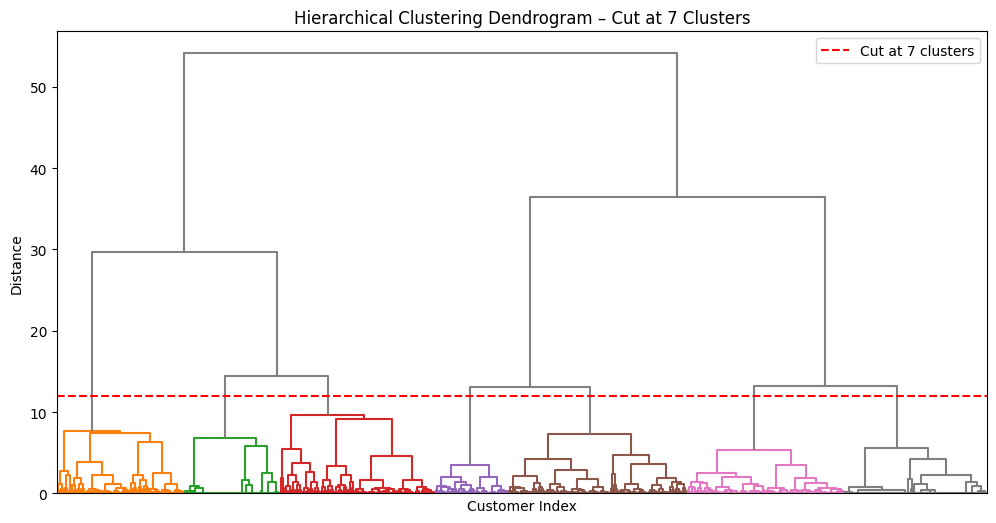

In [67]:
# Create linkage matrix
linkage_matrix = linkage(X_demo_scaled, method='ward')

# Plot dendrogram with cut at 7 clusters
plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    no_labels=True,
    color_threshold=12,   # lower cut to create more clusters
    above_threshold_color='gray'
)

plt.title('Hierarchical Clustering Dendrogram – Cut at 7 Clusters')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.axhline(y=12, color='r', linestyle='--', label='Cut at 7 clusters')
plt.legend()
plt.show()

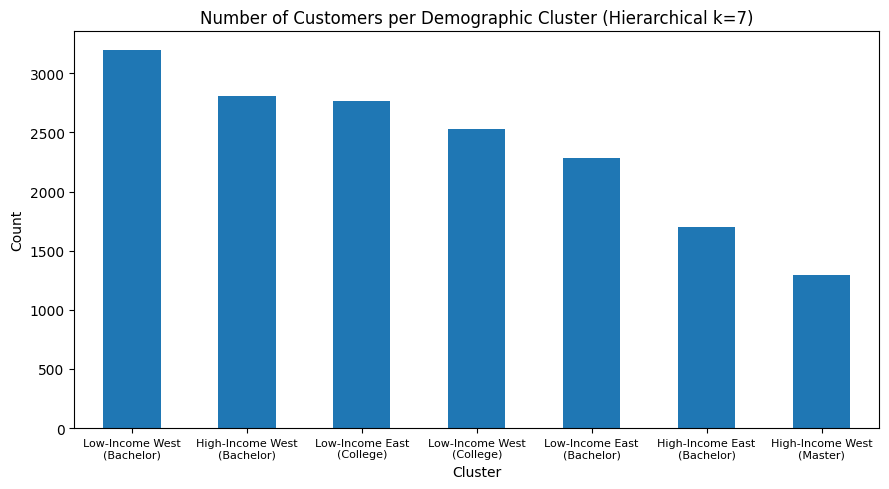

In [90]:
# Agglomerative Clustering k=7
hierarchical_7 = AgglomerativeClustering(n_clusters=7, linkage='ward')
df_demo_ceiled['Cluster_Hierarchical_7'] = hierarchical_7.fit_predict(X_demo_scaled)

# Cluster names for plot (with \n for line break)
hier_7_cluster_names_plot = {
    0: 'Low-Income East\n(College)',
    1: 'Low-Income East\n(Bachelor)',
    2: 'Low-Income West\n(College)',
    3: 'Low-Income West\n(Bachelor)',
    4: 'High-Income East\n(Bachelor)',
    5: 'High-Income West\n(Bachelor)',
    6: 'High-Income West\n(Master)'
}

df_demo_ceiled['Cluster_Hierarchical_7_Name_Plot'] = (
    df_demo_ceiled['Cluster_Hierarchical_7'].map(hier_7_cluster_names_plot)
)

# Plot bar chart
cluster_hier_7_name_counts = df_demo_ceiled['Cluster_Hierarchical_7_Name_Plot'].value_counts()
cluster_hier_7_name_counts.plot(kind='bar', figsize=(9,5))
plt.title('Number of Customers per Demographic Cluster (Hierarchical k=7)')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='center', fontsize=8)
plt.tight_layout()
plt.show()

In [87]:
# Cluster names for profiling
hier_7_cluster_names_profile = {
    0: 'Low-Income East (College)',
    1: 'Low-Income East (Bachelor)',
    2: 'Low-Income West (College)',
    3: 'Low-Income West (Bachelor)',
    4: 'High-Income East (Bachelor)',
    5: 'High-Income West (Bachelor)',
    6: 'High-Income West (Master)'
}

df_demo_ceiled['Cluster_Hierarchical_7_Name'] = (
    df_demo_ceiled['Cluster_Hierarchical_7'].map(hier_7_cluster_names_profile)
)

# Numerical profiling
cluster_profile_hier_7_named = (
    df_demo_ceiled
    .groupby('Cluster_Hierarchical_7_Name')[['Income', 'Latitude', 'Longitude']]
    .mean()
)
print("\nHierarchical Cluster Profiles (k=7):")
print(cluster_profile_hier_7_named)

# Gender
print("\n" + "="*60)
print("Gender Distribution by Cluster (%):")
gender_dist_hier_7 = (
    pd.crosstab(
        df_demo_ceiled['Cluster_Hierarchical_7_Name'],
        df_demo_ceiled['Gender'],
        normalize='index'
    ) * 100
)
print(gender_dist_hier_7.round(2))

# Marital Status
print("\n" + "="*60)
print("Marital Status Distribution by Cluster (%):")
marital_dist_hier_7 = (
    pd.crosstab(
        df_demo_ceiled['Cluster_Hierarchical_7_Name'],
        df_demo_ceiled['Marital Status'],
        normalize='index'
    ) * 100
)
print(marital_dist_hier_7.round(2))

# Education
print("\n" + "="*60)
print("Education Distribution by Cluster (%):")
education_dist_hier_7 = (
    pd.crosstab(
        df_demo_ceiled['Cluster_Hierarchical_7_Name'],
        df_demo_ceiled['Education'],
        normalize='index'
    ) * 100
)
print(education_dist_hier_7.round(2))


Hierarchical Cluster Profiles (k=7):
                                   Income   Latitude   Longitude
Cluster_Hierarchical_7_Name                                     
High-Income East (Bachelor)      0.000000  50.304658 -116.542891
High-Income West (Bachelor)  26088.810253  44.688223  -75.560141
High-Income West (Master)    87706.520093  44.764162  -75.240090
Low-Income East (Bachelor)   73355.634253  50.412842 -117.890791
Low-Income East (College)    31303.300904  50.797223 -116.262017
Low-Income West (Bachelor)   57364.964319  45.009405  -73.867861
Low-Income West (College)      541.754157  44.914415  -74.276288

Gender Distribution by Cluster (%):
Gender                       female   male
Cluster_Hierarchical_7_Name               
High-Income East (Bachelor)   50.35  49.65
High-Income West (Bachelor)   51.30  48.70
High-Income West (Master)     49.23  50.77
Low-Income East (Bachelor)    51.99  48.01
Low-Income East (College)     51.21  48.79
Low-Income West (Bachelor)    49.61  50

In [75]:
# Use the cluster labels for k=7
clusters_hier_7 = df_demo_ceiled['Cluster_Hierarchical_7_Name']

print("\nClustering Quality Metrics (Hierarchical, k=7)")
print("=" * 50)

# Silhouette Score
sil_score_hier_7 = silhouette_score(X_demo_scaled, clusters_hier_7)
print(f"Silhouette Score: {sil_score_hier_7:.4f}")

# Calinski-Harabasz Score
ch_score_hier_7 = calinski_harabasz_score(X_demo_scaled, clusters_hier_7)
print(f"Calinski-Harabasz Score: {ch_score_hier_7:.4f}")

# Davies-Bouldin Score
db_score_hier_7 = davies_bouldin_score(X_demo_scaled, clusters_hier_7)
print(f"Davies-Bouldin Score: {db_score_hier_7:.4f}")


Clustering Quality Metrics (Hierarchical, k=7)
Silhouette Score: 0.3838
Calinski-Harabasz Score: 16763.3162
Davies-Bouldin Score: 0.9059


In [76]:
print("\nR² Score per Variable (Hierarchical, k=7)")
print("=" * 50)

for var in ['Income', 'Latitude', 'Longitude']:
    # Mean of the variable within each k=7 cluster
    cluster_means = df_demo_ceiled.groupby('Cluster_Hierarchical_7_Name')[var].transform('mean')
    r2 = r2_score(df_demo_ceiled[var], cluster_means)
    print(f"{var:12s}: {r2:.4f}")


R² Score per Variable (Hierarchical, k=7)
Income      : 0.9017
Latitude    : 0.7160
Longitude   : 0.8720


The hierarchical clustering with 7 clusters provides a more detailed segmentation compared to k=4, while maintaining strong separation by income and geography. The high R² for Income confirms that income remains the main driver of cluster differentiation, while latitude and longitude continue to contribute to geographic separation. The moderate Silhouette score suggests some overlap between clusters, which is expected with finer segmentation (k=7). Overall, the results indicate a meaningful seven-segment structure, suitable for detailed demographic targeting.

## Hierarchical k=4 vs k=7 Cluster Split

- **High-Income East (k=4):**  
  Mostly splits into **High-Income West B** and **Low-Income West B** in k=7, indicating finer segmentation within the high-income group.

- **High-Income West (k=4):**  
  Almost entirely maps to **Low-Income West B** in k=7, suggesting some anomalies or small subgroup distinctions.

- **Low-Income East (k=4):**  
  Divides primarily into **Low-Income East A** and **Low-Income East B** in k=7, showing that the k=7 segmentation captures subgroups with different income or geographic characteristics.

- **Low-Income West (k=4):**  
  Splits mainly into **Low-Income West A** and **High-Income East** in k=7, reflecting small high/low-income subgroups and potentially outlier customers.

**Interpretation:**  
- Moving from k=4 to k=7 **adds more granularity**, particularly for income segmentation.  
- Most of the new clusters are meaningful subdivisions rather than entirely new demographic types.  
- A few very small or anomalous clusters appear (e.g., High-Income East = 0, Low-Income West A = 542), which should be noted in analysis or potentially handled as outliers.

For practical purposes, k=4 remains the preferred choice since it captures the main demographic segments clearly, keeps interpretation simple, and avoids overcomplicating the model with tiny clusters.

## K-Means k=4 vs Hierarchical k=4

**Clustering Quality Metrics:**

| Metric                  | Hierarchical k=4 | K-Means k=4 |
|-------------------------|-----------------|-------------|
| Silhouette Score        | 0.4752          | 0.5000      |
| Calinski-Harabasz Score | 19,030.12       | 20,818.00   |
| Davies-Bouldin Score    | 0.7379          | 0.7300      |
| R² Income               | 0.7218          | 0.7451      |
| R² Latitude             | 0.7139          | 0.7033      |
| R² Longitude            | 0.8716          | 0.8889      |

**Cluster Profiles (Mean Values):**

- **High-Income East:**  
  - Hierarchical: 66,111 USD, Lat 44.94, Lon -74.26  
  - K-Means: 68,149 USD, Lat 44.94, Lon -74.85  
- **High-Income West:**  
  - Hierarchical: 73,356 USD, Lat 50.41, Lon -117.89  
  - K-Means: 68,331 USD, Lat 50.61, Lon -118.01  
- **Low-Income East:**  
  - Hierarchical: 13,993 USD, Lat 44.80, Lon -74.95  
  - K-Means: 15,282 USD, Lat 44.96, Lon -75.12  
- **Low-Income West:**  
  - Hierarchical: 19,385 USD, Lat 50.61, Lon -116.37  
  - K-Means: 15,108 USD, Lat 50.64, Lon -117.91  

**Demographics:**

- Gender distribution is balanced in both methods.  
- Marital status: High-income clusters show higher marriage rates (~68%), low-income clusters lower (~50%).  
- Education: High-income clusters almost entirely Bachelor’s degree, low-income clusters show more diversity.  

**Interpretation:**

- Both methods identify **similar broad demographic segments**, dominated by **income and geographic location**.  
- **K-Means slightly outperforms Hierarchical** on Silhouette and R² Income, suggesting slightly better cohesion and variance explanation in income.  
- **Hierarchical clusters** show a slightly higher separation in Latitude (better geographic distinction).  

Overall, both methods are valid, but we will use **K-Means k=4** for the final demographic segmentation due to its slightly better cluster cohesion, variance explanation, and clear centroid-based structure.

In [89]:
# Export final cluster assignments for merging with other perspectives
final_clusters = pd.DataFrame(index=df_AIAI_Master.index)
final_clusters.index.name = 'Loyalty#'
final_clusters['Demographic_Cluster'] = df_demo_ceiled['Cluster']
final_clusters['Demographic_Cluster_Name'] = df_demo_ceiled['Cluster_Name']

# Reset index to make Loyalty# a column
final_clusters = final_clusters.reset_index()

# Save to CSV
final_clusters.to_csv('demographic_clusters.csv', index=False)

print("Exported demographic cluster assignments:")
print(final_clusters.head(10))
print(f"\nTotal customers: {len(final_clusters)}")
print(f"\nCluster distribution:")
print(final_clusters['Demographic_Cluster_Name'].value_counts())

Exported demographic cluster assignments:
   Loyalty#  Demographic_Cluster Demographic_Cluster_Name
0    480934                    3         High-Income East
1    549612                    2          Low-Income West
2    429460                    2          Low-Income West
3    608370                    0          Low-Income East
4    530508                    3         High-Income East
5    927943                    0          Low-Income East
6    188893                    3         High-Income East
7    852392                    3         High-Income East
8    866307                    3         High-Income East
9    932823                    1         High-Income West

Total customers: 16572

Cluster distribution:
Demographic_Cluster_Name
Low-Income East     5793
High-Income East    4282
Low-Income West     3735
High-Income West    2762
Name: count, dtype: int64
